# AIRPATH-AI Milestone 3D — end-to-end forecast + spatial validation

This notebook reproduces the development-only comparison of:

1. forecast-only station PM2.5;
2. oracle IDW p=1 from observed peer stations;
3. forecast+IDW p=1 from forecasted peer stations.

It uses persisted V1 validation predictions generated from training-period fits. It does not retrain models, use the exposed forecasting test period for selection, calculate exposure, or optimize routes. Route-segment references are hourly oracle-IDW pseudo-references—not road measurements.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.end_to_end_validation import generate_validation_outputs

In [2]:
output_directory = PROJECT_ROOT / "data/processed/end_to_end_validation"
outputs = generate_validation_outputs(
    prediction_csv=PROJECT_ROOT / "data/processed/xgboost_forecasting_predictions.csv",
    network_path=PROJECT_ROOT / "data/processed/road_network/healthyair_pilot_osm.json.gz",
    output_directory=output_directory,
    report_path=PROJECT_ROOT / "reports/end_to_end_validation.md",
)
outputs["metrics"].loc[outputs["metrics"]["aggregation"].eq("pooled")]

,pipeline,aggregation,held_out_station,horizon_hours,n,unique_target_timestamps,mae,rmse,r2
0,forecast_only,pooled,ALL,ALL,20664,1183,5.462220,7.925682,0.473065
28,oracle_spatial,pooled,ALL,ALL,20664,1183,5.441592,8.039164,0.457867
56,forecast_spatial,pooled,ALL,ALL,20664,1183,6.911591,9.504291,0.242255


In [3]:
display(outputs["metrics"].loc[outputs["metrics"]["aggregation"].eq("per_horizon")])
display(outputs["decomposition"])

,pipeline,aggregation,held_out_station,horizon_hours,n,unique_target_timestamps,mae,rmse,r2
7,forecast_only,per_horizon,ALL,1,6930,1155,4.572125,6.937710,0.593352
8,forecast_only,per_horizon,ALL,2,6882,1147,5.567721,8.031978,0.462907
9,forecast_only,per_horizon,ALL,3,6852,1142,6.256485,8.715764,0.362495
35,oracle_spatial,per_horizon,ALL,1,6930,1155,5.423335,7.922474,0.469716
36,oracle_spatial,per_horizon,ALL,2,6882,1147,5.445705,8.076728,0.456906
37,oracle_spatial,per_horizon,ALL,3,6852,1142,5.455924,8.118124,0.446925
63,forecast_spatial,per_horizon,ALL,1,6930,1155,6.378692,8.919158,0.327899
64,forecast_spatial,per_horizon,ALL,2,6882,1147,6.948242,9.570175,0.237493
65,forecast_spatial,per_horizon,ALL,3,6852,1142,7.413743,9.998612,0.161019


,horizon_hours,forecast_only_mae,oracle_spatial_mae,forecast_spatial_mae,combined_minus_oracle_mae,combined_minus_forecast_only_mae,forecast_only_rmse,oracle_spatial_rmse,forecast_spatial_rmse,combined_minus_oracle_rmse,combined_minus_forecast_only_rmse,forecast_only_r2,oracle_spatial_r2,forecast_spatial_r2,combined_minus_oracle_r2,combined_minus_forecast_only_r2
0,ALL,5.462220,5.441592,6.911591,1.469999,1.449370,7.925682,8.039164,9.504291,1.465127,1.578610,0.473065,0.457867,0.242255,-0.215613,-0.230810
1,1,4.572125,5.423335,6.378692,0.955357,1.806567,6.937710,7.922474,8.919158,0.996684,1.981449,0.593352,0.469716,0.327899,-0.141817,-0.265452
2,2,5.567721,5.445705,6.948242,1.502537,1.380521,8.031978,8.076728,9.570175,1.493447,1.538197,0.462907,0.456906,0.237493,-0.219413,-0.225414
3,3,6.256485,5.455924,7.413743,1.957819,1.157258,8.715764,8.118124,9.998612,1.880489,1.282848,0.362495,0.446925,0.161019,-0.285906,-0.201476


In [4]:
display(outputs["mapping_metrics"])
display(
    outputs["route_sample"][[
        "mode",
        "segment_index",
        "eta",
        "mapped_target_time",
        "oracle_spatial_pm25",
        "forecast_spatial_pm25",
        "absolute_error",
        "reliability_status",
    ]]
)

,mode,mapping_rule,segments,mapped_target_hours,mae_vs_oracle_spatial,rmse_vs_oracle_spatial,max_absolute_error
0,motorbike,ceiling,133,1,4.034475,4.522641,6.679746
1,motorbike,floor,133,1,1.462074,1.529898,2.697593
2,motorbike,nearest,133,1,1.462074,1.529898,2.697593
3,walking,ceiling,121,1,4.373597,4.755687,6.679746
4,walking,floor,121,1,1.395071,1.459377,2.697593
5,walking,nearest,121,2,1.528210,1.719921,3.607944


,mode,segment_index,eta,mapped_target_time,oracle_spatial_pm25,forecast_spatial_pm25,absolute_error,reliability_status
0,motorbike,1,2022-02-28 06:00:12.255383185,2022-02-28 07:00:00,33.258038,26.684585,6.573454,supported
1,motorbike,2,2022-02-28 06:00:29.675284872,2022-02-28 07:00:00,33.196144,26.564957,6.631187,supported
2,motorbike,3,2022-02-28 06:00:41.278449392,2022-02-28 07:00:00,33.146262,26.496132,6.650130,supported
3,walking,1,2022-02-28 06:01:01.276915927,2022-02-28 07:00:00,33.258038,26.684585,6.573454,supported
4,walking,2,2022-02-28 06:02:28.376424359,2022-02-28 07:00:00,33.196144,26.564957,6.631187,supported
5,walking,3,2022-02-28 06:03:26.392246959,2022-02-28 07:00:00,33.146262,26.496132,6.650130,supported
6,motorbike,133,2022-02-28 06:09:12.899526607,2022-02-28 07:00:00,15.669957,17.331806,1.661849,supported
7,walking,121,2022-02-28 06:46:13.918312141,2022-02-28 07:00:00,15.669957,17.331806,1.661849,supported


In [5]:
display(outputs["correlations"])
display(outputs["status_metrics"])
outputs["decision"]

,analysis,error_measure,proxy,n,spearman_rank_correlation
0,heldout_station_aggregate,combined_mae,nearest_station_distance_km,6,-0.231908
1,heldout_station_aggregate,combined_mae,second_nearest_station_distance_km,6,-0.318874
2,heldout_station_aggregate,combined_mae,maximum_idw_weight,6,0.371429
3,heldout_station_aggregate,combined_mae,effective_station_count,6,-0.028571
4,route_segments_ceiling,absolute_forecast_minus_oracle_spatial,nearest_station_distance_km,254,0.236884
5,route_segments_ceiling,absolute_forecast_minus_oracle_spatial,second_nearest_station_distance_km,254,-0.216475
6,route_segments_ceiling,absolute_forecast_minus_oracle_spatial,maximum_idw_weight,254,-0.245710
7,route_segments_ceiling,absolute_forecast_minus_oracle_spatial,effective_station_count,254,0.251723


,mode,reliability_status,segments,mae_vs_oracle_spatial,rmse_vs_oracle_spatial
0,motorbike,moderate reliability,3,4.211240,4.410142
1,motorbike,supported,130,4.030396,4.525204
2,walking,moderate reliability,8,3.570076,3.692597
3,walking,supported,113,4.430484,4.822075


ReadinessDecision(classification='B. READY WITH RESTRICTIONS', rationale='Combined error meets pooled usability criteria and generalizes positively at at least four stations, but not every strict criterion.', criteria={'combined_mae_relative_to_worse_component': 1.2653444956096038, 'combined_mae_degradation_le_50_percent': True, 'pooled_r2_positive': True, 'at_least_four_of_six_station_r2_positive': True, 'positive_station_r2_count': 5, 'ready_strict_mae_degradation_le_10_percent': False, 'ready_strict_r2_no_worse_than_component_floor': False, 'ready_strict_all_station_r2_nonnegative': False})

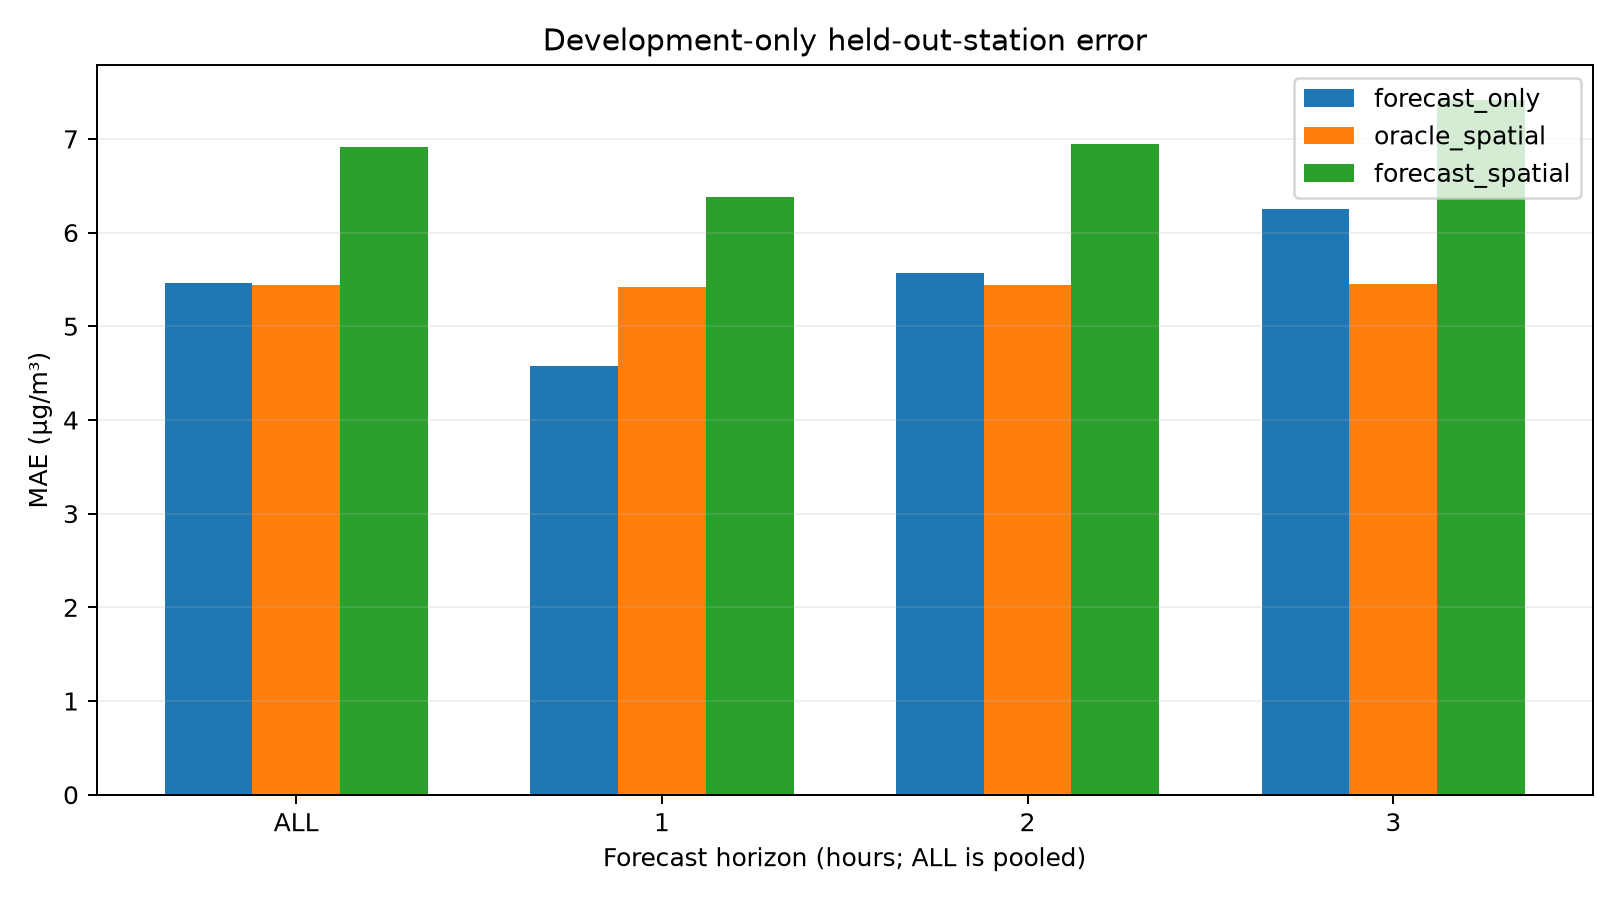

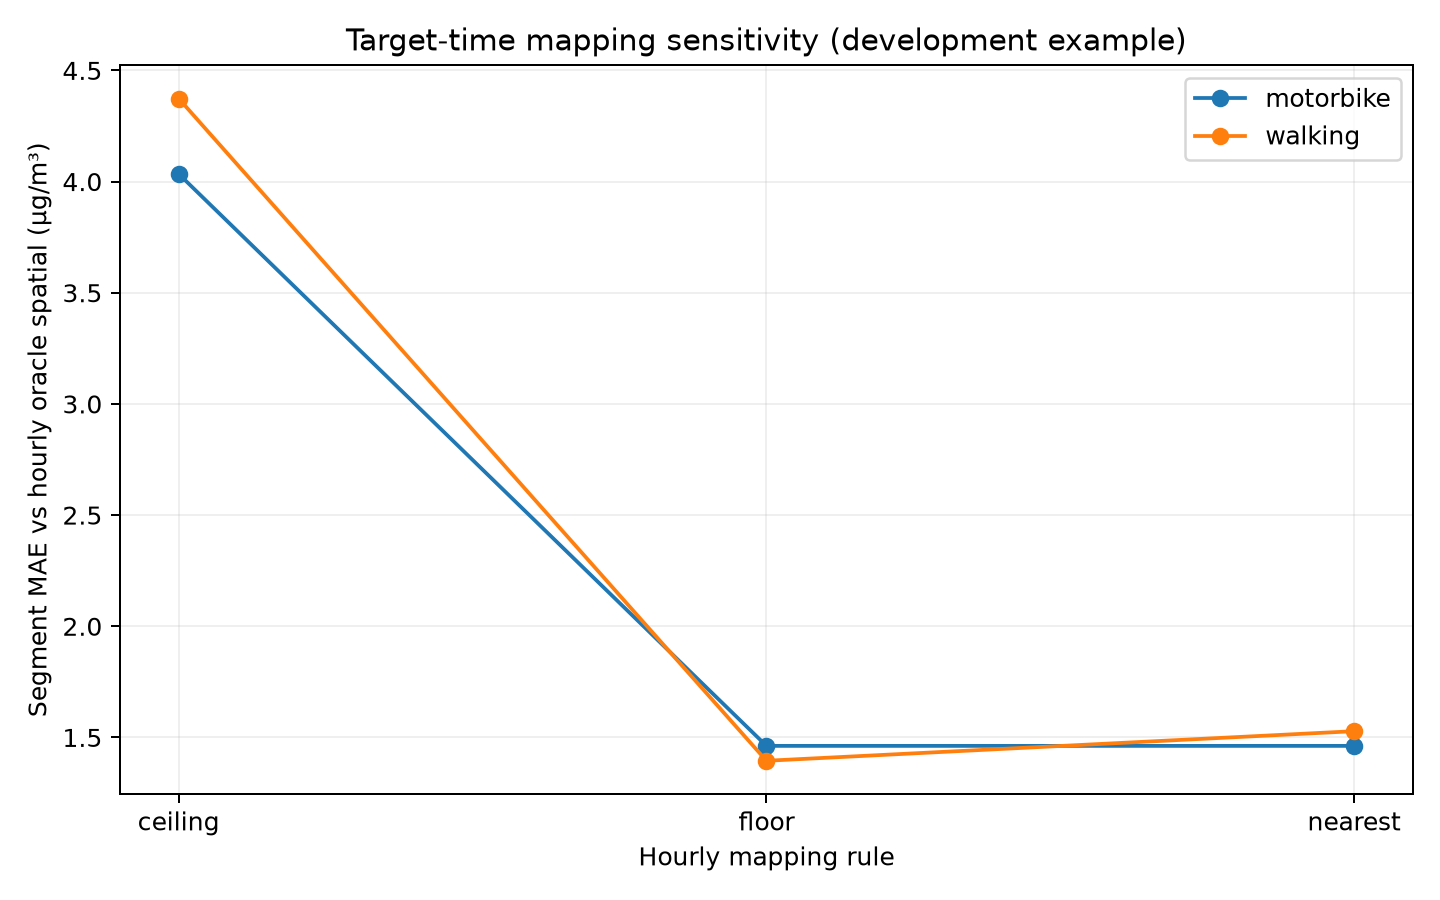

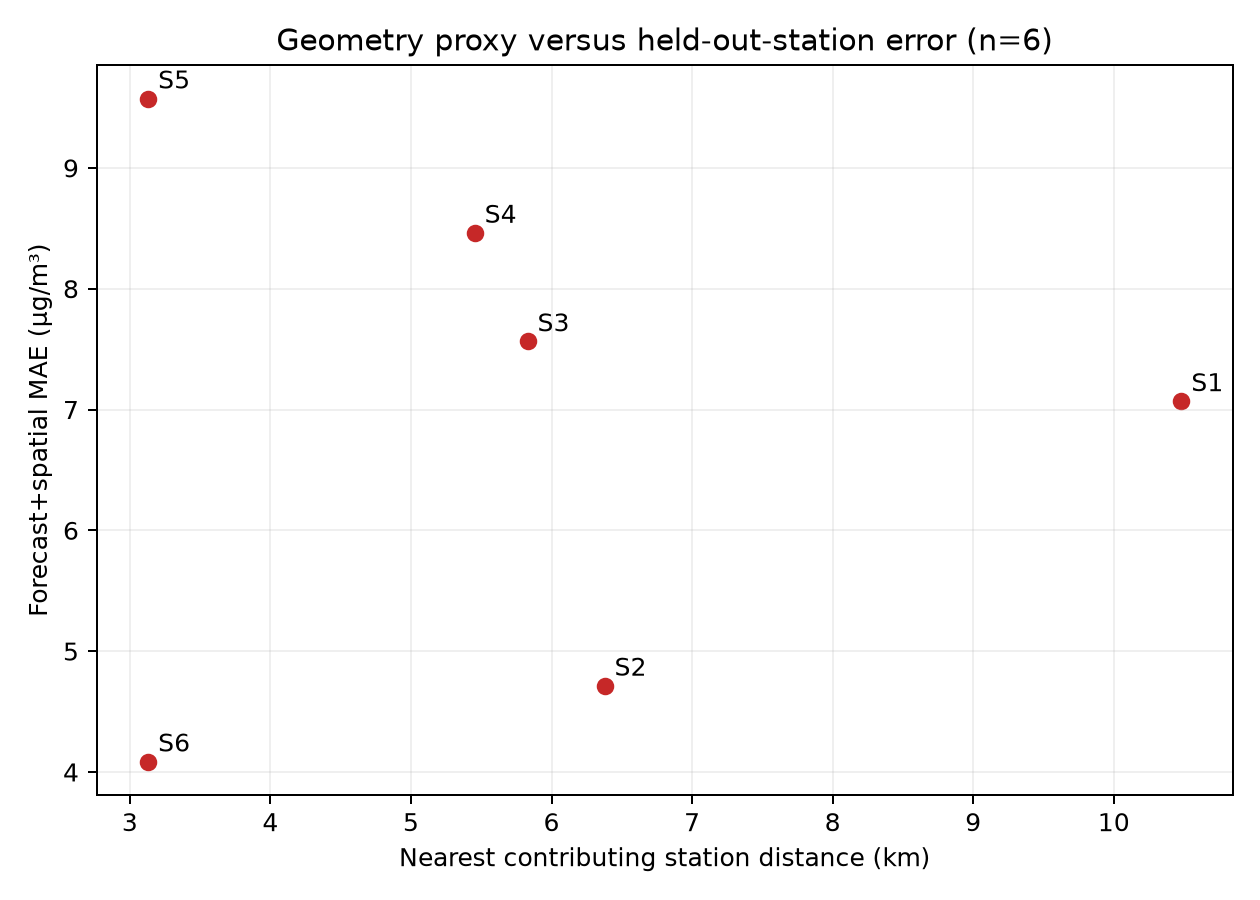

In [6]:
for filename in (
    "heldout_pipeline_mae.png",
    "mapping_sensitivity.png",
    "reliability_error_proxy.png",
):
    display(Image(filename=output_directory / filename))

## Interpretation boundary

Current HealthyAir validation is hourly. Ceiling, floor, and nearest mappings select an observed/predicted hourly target without interpolation. None validates PM2.5 at an exact minute-level arrival time.

The readiness decision permits only a restricted offline exposure-aggregation experiment. It does not authorize route recommendation or optimization, and station 5's negative combined R² remains a material limitation.